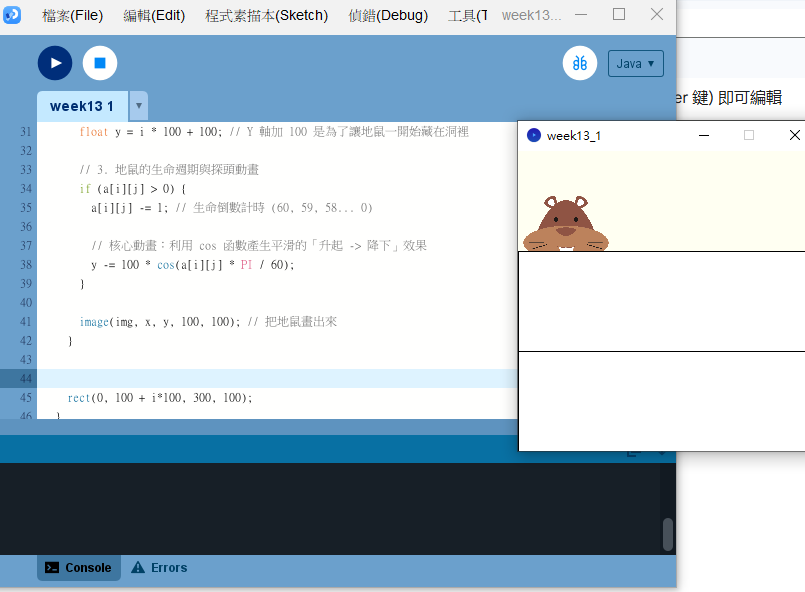

```java
// 接續 week12-1 week11-1 程式 (3x3 打地鼠)
PImage img; // 宣告圖片變數

void setup() {
  size(300, 300); // 視窗大小 300x300 (剛好可以切成 3x3 的 100x100 九宮格)
  img = loadImage("gopher.png"); // 載入地鼠圖片
}

// 宣告一個 3x3 的二維陣列，用來記錄 9 個地洞的狀態 (數字代表地鼠探出頭的剩餘時間)
int[][] a = {
  {0, 0, 0},
  {0, 0, 0},
  {0, 0, 0}
};

void draw() {
  background(#FFFFF2); // 淡黃色背景
  
  // 1. 亂數產生器：每 60 個 frame (約 1 秒)，就隨機挑一個洞讓地鼠冒出來
  if (frameCount % 60 == 0) {
    int i = int(random(3)); // 隨機挑選列 (0, 1, 2)
    int j = int(random(3)); // 隨機挑選欄 (0, 1, 2)
    a[i][j] = 60; // 給這隻幸運地鼠 60 frames (1秒鐘) 的出場壽命
  }
  
  // 2. 繪製 3x3 九宮格
  for (int i=0; i<3; i++) {
    for (int j=0; j<3; j++) {
      // 算好每個地洞的基本座標
      float x = j * 100;
      float y = i * 100 + 100; // Y 軸加 100 是為了讓地鼠一開始藏在洞裡
      
      // 3. 地鼠的生命週期與探頭動畫
      if (a[i][j] > 0) {
        a[i][j] -= 1; // 生命倒數計時 (60, 59, 58... 0)
        
        // 核心動畫：利用 cos 函數產生平滑的「升起 -> 降下」效果
        y -= 100 * cos(a[i][j] * PI / 60);
      }
      
      image(img, x, y, 100, 100); // 把地鼠畫出來
    }
    

    rect(0, 100 + i*100, 300, 100);
  }
}
```

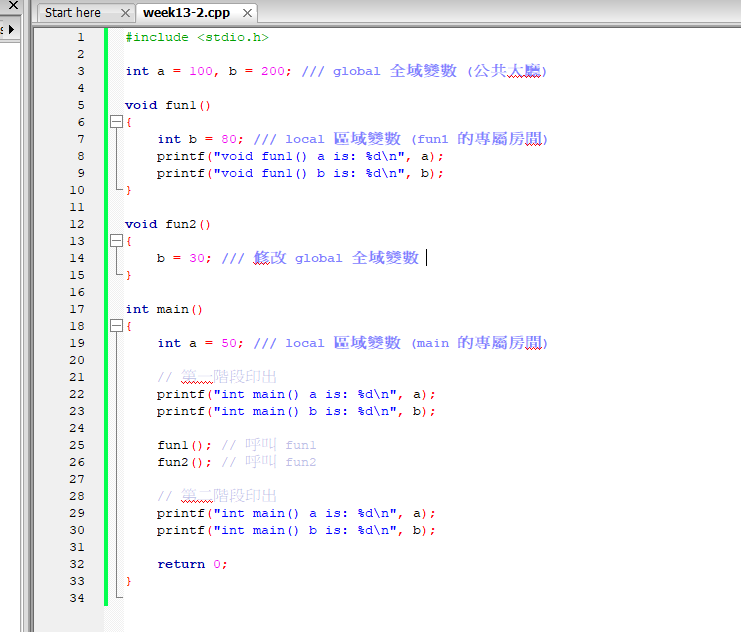

```cpp
#include <stdio.h>

int a = 100, b = 200; /// global 全域變數 (公共大廳)

void fun1()
{
    int b = 80; /// local 區域變數 (fun1 的專屬房間)
    printf("void fun1() a is: %d\n", a);
    printf("void fun1() b is: %d\n", b);
}

void fun2()
{
    b = 30; /// 修改 global 全域變數
}

int main()
{
    int a = 50; /// local 區域變數 (main 的專屬房間)

    // 第一階段印出
    printf("int main() a is: %d\n", a);
    printf("int main() b is: %d\n", b);

    fun1(); // 呼叫 fun1
    fun2(); // 呼叫 fun2

    // 第二階段印出
    printf("int main() a is: %d\n", a);
    printf("int main() b is: %d\n", b);

    return 0;
}
```

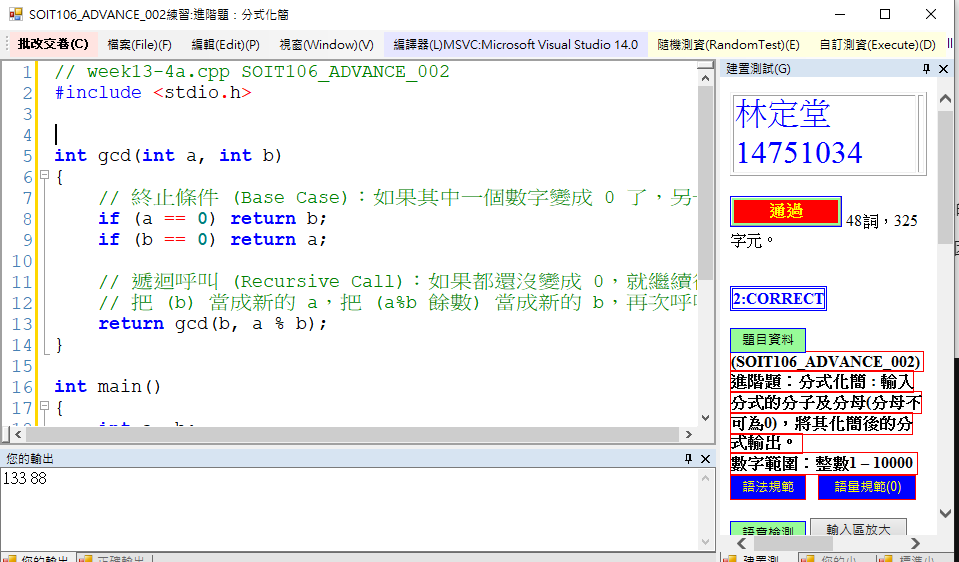

```cpp
// week13-4a.cpp SOIT106_ADVANCE_002
#include <stdio.h>


int gcd(int a, int b)
{
    // 終止條件 (Base Case)：如果其中一個數字變成 0 了，另一個數字就是答案
    if (a == 0) return b;
    if (b == 0) return a;
    
    // 遞迴呼叫 (Recursive Call)：如果都還沒變成 0，就繼續往下除
    // 把 (b) 當成新的 a，把 (a%b 餘數) 當成新的 b，再次呼叫自己！
    return gcd(b, a % b);
}

int main()
{
    int a, b;
    scanf("%d%d", &a, &b);
    
    // 呼叫我們自己寫的 gcd 函式來幫忙算答案
    int ans = gcd(a, b);
    
    // 印出約分後的結果
    printf("%d %d\n", a/ans, b/ans);
    
    return 0;
}
```

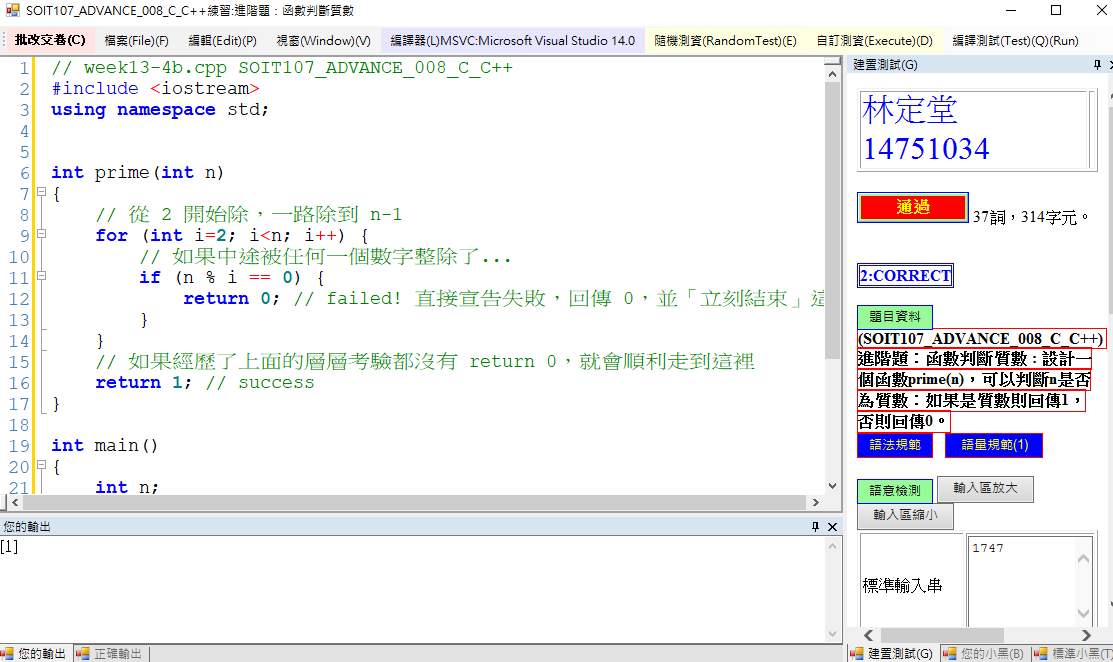

```cpp
// week13-4b.cpp SOIT107_ADVANCE_008_C_C++
#include <iostream>
using namespace std;


int prime(int n)
{
    // 從 2 開始除，一路除到 n-1
    for (int i=2; i<n; i++) {
        // 如果中途被任何一個數字整除了...
        if (n % i == 0) {
            return 0; // failed! 直接宣告失敗，回傳 0，並「立刻結束」這個函式
        }
    }
    // 如果經歷了上面的層層考驗都沒有 return 0，就會順利走到這裡
    return 1; // success
}

int main()
{
    int n;
    cin >> n; //
    

    cout << "[" << prime(n) << "]";
    
    return 0;
}
```

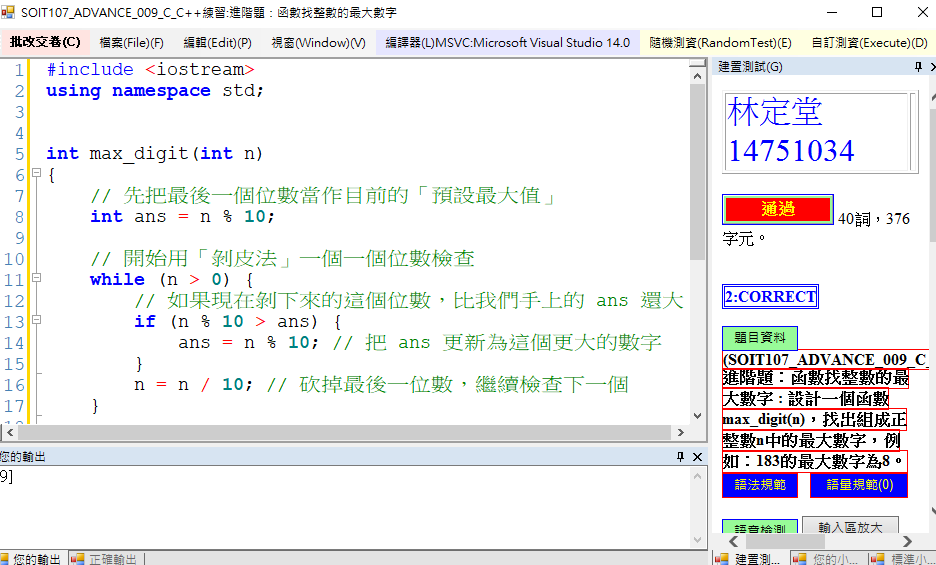

```cpp
#include <iostream>
using namespace std;


int max_digit(int n)
{
    // 先把最後一個位數當作目前的「預設最大值」
    int ans = n % 10;
    
    // 開始用「剝皮法」一個一個位數檢查
    while (n > 0) {
        // 如果現在剝下來的這個位數，比我們手上的 ans 還大
        if (n % 10 > ans) {
            ans = n % 10; // 把 ans 更新為這個更大的數字
        }
        n = n / 10; // 砍掉最後一位數，繼續檢查下一個
    }
    
 了
    return ans;
}

int main() {
    int n;
    cin >> n; // 讀取使用者輸入的數字
    
    // 呼叫函式，並用中括號包起來印出結果
    cout << "[" << max_digit(n) << "]";
    
    return 0;
}
```

S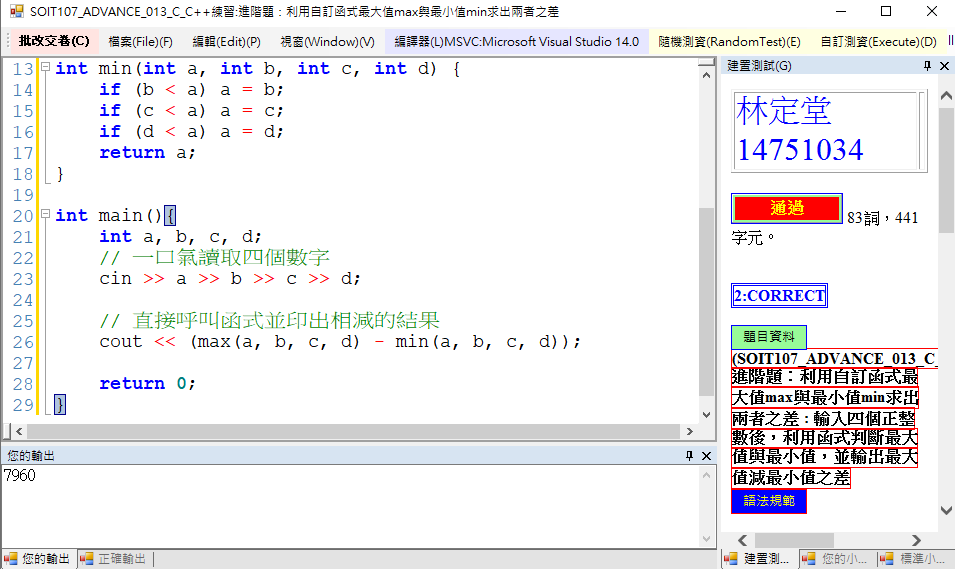

```cpp
#include<iostream>
using namespace std;

// 填補缺失的 max 函式 (打擂台法)
int max(int a, int b, int c, int d) {
    if (b > a) a = b;
    if (c > a) a = c;
    if (d > a) a = d;
    return a;
}

// 填補缺失的 min 函式 (打擂台法)
int min(int a, int b, int c, int d) {
    if (b < a) a = b;
    if (c < a) a = c;
    if (d < a) a = d;
    return a;
}

int main(){
    int a, b, c, d;
    // 一口氣讀取四個數字
    cin >> a >> b >> c >> d;
    
    // 直接呼叫函式並印出相減的結果
    cout << (max(a, b, c, d) - min(a, b, c, d));
    
    return 0;
}
```

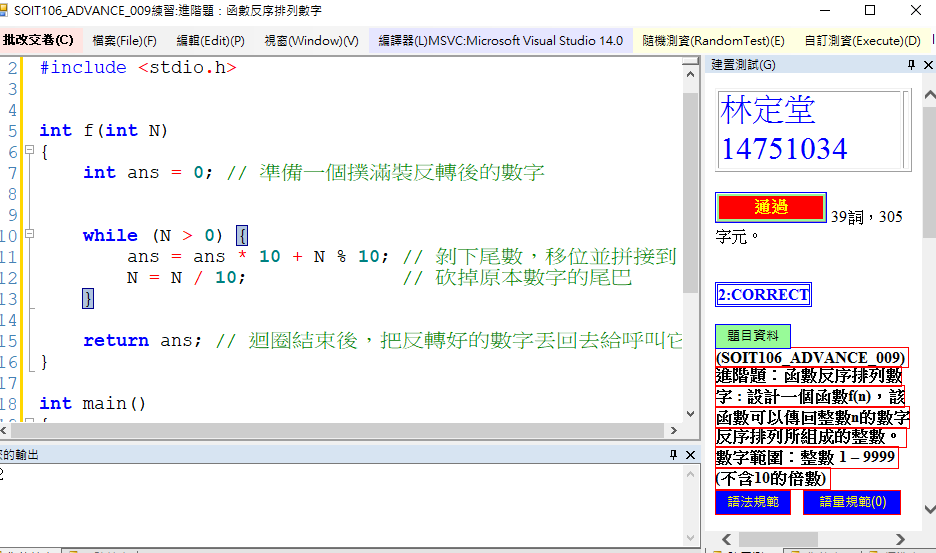

```cpp
#include <stdio.h>


int f(int N)
{
    int ans = 0; // 準備一個撲滿裝反轉後的數字


    while (N > 0) {
        ans = ans * 10 + N % 10; // 剝下尾數，移位並拼接到 ans
        N = N / 10;              // 砍掉原本數字的尾巴
    }

    return ans; // 迴圈結束後，把反轉好的數字丟回去給呼叫它的人
}

int main()
{
    int N;
    scanf("%d", &N); // 讀取使用者輸入的數字


    printf("%d\n", f(N));

    return 0;
}
```